In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from lifelines import KaplanMeierFitter

In [2]:
# Load dataset
data = pd.read_excel("C:/Users/luenx/OneDrive/Desktop/UMP/UMP/Sem 6/group project/final ridership.xlsx")


In [3]:
# Convert Date
data['Date'] = pd.to_datetime(data['Date'])


In [4]:
# Remove dashes from string columns
for col in data.columns:
    if data[col].dtype == object:
        data[col] = data[col].str.replace('-', '', regex=True)


In [7]:
# Fill missing values
cols_to_fill = ['Failure RS', 'Failure TNM', 'Failure POW', 'Failure SIG',
                'Total Failure', 'Relevant Failure', 'Service Downtime']
for col in cols_to_fill:
    data[col] = data[col].fillna(0)  


In [10]:
# Drop unused column
data = data.drop("Total Ridership", axis=1)


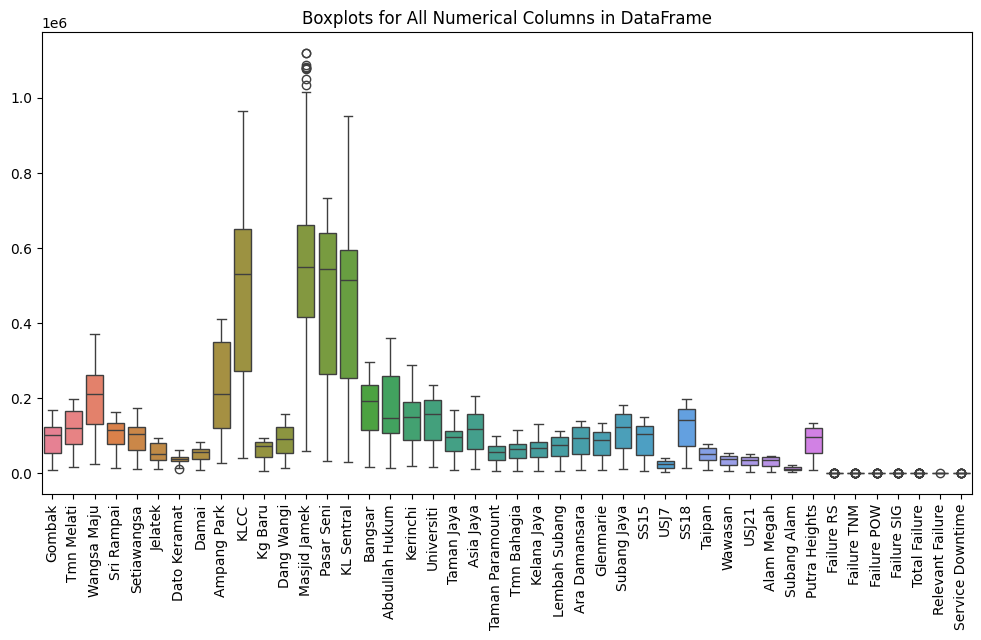

In [11]:
# Boxplot
ridership = data.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 6))
sns.boxplot(data=ridership)
plt.xticks(rotation=90)
plt.title('Boxplots for All Numerical Columns in DataFrame')
plt.show()


In [12]:
def schedule_maintenance(probability, threshold=0.7):
    if probability < threshold:
        return "Perform immediate maintenance."
    return "Regular maintenance schedule is adequate."

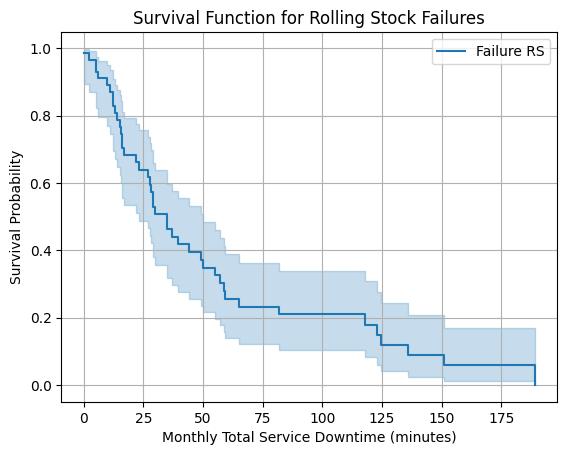

Rolling Stock | Avg Downtime: 37.21 min | Reliability: 0.44
Perform immediate maintenance.


In [14]:
# ── RS Failures ──────────────────────────────────────────
rs_failures = data[['Date', 'Service Downtime', 'Failure RS']].copy()
rs_failures['Event Observed'] = rs_failures['Failure RS'].apply(lambda x: 1 if x > 0 else 0)

kmf_rs = KaplanMeierFitter()
kmf_rs.fit(durations=rs_failures['Service Downtime'],
           event_observed=rs_failures['Event Observed'], label='Failure RS')
kmf_rs.plot_survival_function()
plt.title('Survival Function for Rolling Stock Failures')
plt.xlabel('Monthly Total Service Downtime (minutes)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

average_downtime_rs = rs_failures['Service Downtime'].mean()
current_prob_rs = kmf_rs.survival_function_at_times(average_downtime_rs).values[0]
print(f"Rolling Stock | Avg Downtime: {average_downtime_rs:.2f} min | Reliability: {current_prob_rs:.2f}")
print(schedule_maintenance(current_prob_rs))

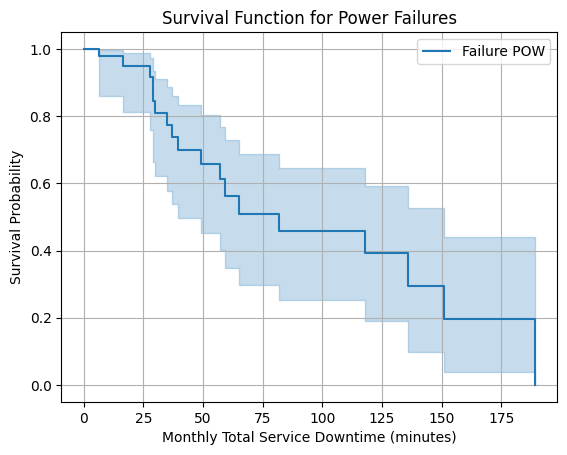

Power Failures | Avg Downtime: 37.21 min | Reliability: 0.74
Regular maintenance schedule is adequate.


In [16]:
# ── POW Failures ─────────────────────────────────────────
pow_failures = data[['Date', 'Service Downtime', 'Failure POW']].copy()
pow_failures['Event Observed'] = pow_failures['Failure POW'].apply(lambda x: 1 if x > 0 else 0)

kmf_pow = KaplanMeierFitter()
kmf_pow.fit(durations=pow_failures['Service Downtime'],
            event_observed=pow_failures['Event Observed'], label='Failure POW')
kmf_pow.plot_survival_function()
plt.title('Survival Function for Power Failures')
plt.xlabel('Monthly Total Service Downtime (minutes)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

average_downtime_pow = pow_failures['Service Downtime'].mean()
current_prob_pow = kmf_pow.survival_function_at_times(average_downtime_pow).values[0]
print(f"Power Failures | Avg Downtime: {average_downtime_pow:.2f} min | Reliability: {current_prob_pow:.2f}")
print(schedule_maintenance(current_prob_pow))

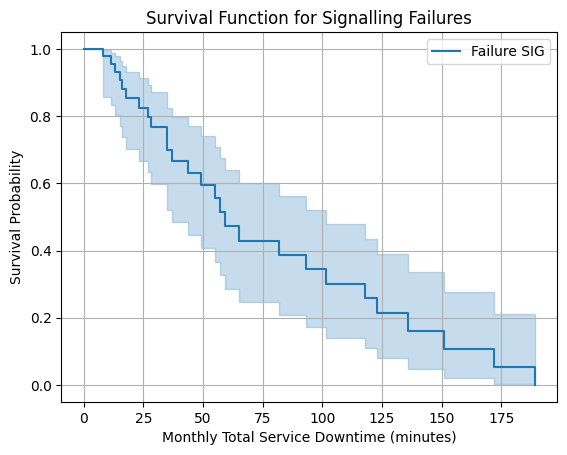

Signal Failures | Avg Downtime: 37.21 min | Reliability: 0.67
Perform immediate maintenance.


In [18]:
# ── SIG Failures ─────────────────────────────────────────
sig_failures = data[['Date', 'Service Downtime', 'Failure SIG']].copy()
sig_failures['Event Observed'] = sig_failures['Failure SIG'].apply(lambda x: 1 if x > 0 else 0)

kmf_sig = KaplanMeierFitter()
kmf_sig.fit(durations=sig_failures['Service Downtime'],
            event_observed=sig_failures['Event Observed'], label='Failure SIG')
kmf_sig.plot_survival_function()
plt.title('Survival Function for Signalling Failures')
plt.xlabel('Monthly Total Service Downtime (minutes)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

average_downtime_sig = sig_failures['Service Downtime'].mean()
current_prob_sig = kmf_sig.survival_function_at_times(average_downtime_sig).values[0]
print(f"Signal Failures | Avg Downtime: {average_downtime_sig:.2f} min | Reliability: {current_prob_sig:.2f}")
print(schedule_maintenance(current_prob_sig))

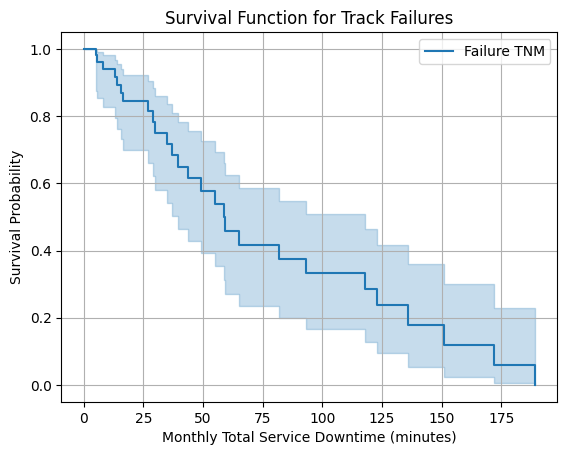

Track Failures | Avg Downtime: 37.21 min | Reliability: 0.68
Perform immediate maintenance.


In [19]:
# ── TNM Failures ─────────────────────────────────────────
tnm_failures = data[['Date', 'Service Downtime', 'Failure TNM']].copy()
tnm_failures['Event Observed'] = tnm_failures['Failure TNM'].apply(lambda x: 1 if x > 0 else 0)

kmf_tnm = KaplanMeierFitter()
kmf_tnm.fit(durations=tnm_failures['Service Downtime'],
            event_observed=tnm_failures['Event Observed'], label='Failure TNM')
kmf_tnm.plot_survival_function()
plt.title('Survival Function for Track Failures')
plt.xlabel('Monthly Total Service Downtime (minutes)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

average_downtime_tnm = tnm_failures['Service Downtime'].mean()
current_prob_tnm = kmf_tnm.survival_function_at_times(average_downtime_tnm).values[0]
print(f"Track Failures | Avg Downtime: {average_downtime_tnm:.2f} min | Reliability: {current_prob_tnm:.2f}")
print(schedule_maintenance(current_prob_tnm))

In [20]:
# ── Comparison Table ──────────────────────────────────────
comparison_data = {                                        
    "System Failure": ["RS", "POW", "SIG", "TNM"],
    "Average Downtime (minutes)": [average_downtime_rs, average_downtime_pow,
                                   average_downtime_sig, average_downtime_tnm],
    "Reliability at Average Downtime": [current_prob_rs, current_prob_pow,
                                        current_prob_sig, current_prob_tnm],
    "Maintenance Decision": [
        schedule_maintenance(current_prob_rs),
        schedule_maintenance(current_prob_pow),
        schedule_maintenance(current_prob_sig),
        schedule_maintenance(current_prob_tnm)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

  System Failure  Average Downtime (minutes)  Reliability at Average Downtime  \
0             RS                   37.210938                         0.440397   
1            POW                   37.210938                         0.736986   
2            SIG                   37.210938                         0.667159   
3            TNM                   37.210938                         0.682847   

                        Maintenance Decision  
0             Perform immediate maintenance.  
1  Regular maintenance schedule is adequate.  
2             Perform immediate maintenance.  
3             Perform immediate maintenance.  
